In [1]:
import re
import unidecode
import string
import random

import torch
import torch.nn as nn
from torch.autograd import Variable

## Scarichiamo il nostro dataset

In [2]:
all_characters = string.printable
n_characters = len(all_characters)

text = unidecode.unidecode(open("content/alice.txt", 'rb').read().decode(encoding='utf-8'))
text_len = len(text)
print('text_len =', text_len)


text_len = 148574


In [3]:
def random_chunk(text, chunk_len = 200):
    start_index = random.randint(0, text_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return text[start_index:end_index]

print(random_chunk(text))


 after her as she went out,
but it just missed her.

  Alice caught the baby with some difficulty, as it was a queer-
shaped little creature, and held out its arms and legs in all
directions, `just lik


In [4]:
vocab = sorted(set(text))
print(f'{len(vocab)} unique characters')

72 unique characters


In [5]:
# class GRU(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size, n_layers=1):
#         super(GRU, self).__init__()
#         self.input_size = input_size
#         self.hidden_size = hidden_size
#         self.output_size = output_size
#         self.n_layers = n_layers

#         self.encoder = nn.Embedding(input_size, hidden_size)
#         self.gru = nn.GRU(hidden_size, hidden_size, n_layers)
#         self.decoder = nn.Linear(hidden_size, output_size)

#     def forward(self, input, hidden):
#         input = self.encoder(input.view(1, -1))
#         output, hidden = self.gru(input.view(1, 1, -1), hidden)
#         output = self.decoder(output.view(1, -1))
#         return output, hidden

#     def init_hidden(self):
#         return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))


In [6]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=2):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        self.encoder = nn.Embedding(input_size, hidden_size)
        self.LSTM = nn.LSTM(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden):
        embedded = self.encoder(input.view(1, -1)) #flattening
        output, (hidden_state, cell_state) = self.LSTM(embedded.view(1, 1, -1), hidden) #computes lstm memory
        output = self.decoder(output.view(1, -1)) #predicts tokens
        return output, (hidden_state, cell_state)

    def init_hidden(self):
        return (
            torch.zeros(self.n_layers, 1, self.hidden_size),
            torch.zeros(self.n_layers, 1, self.hidden_size)
                )

In [7]:
from torchsummary import summary

In [8]:
def char_tensor(string):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = all_characters.index(string[c])
    return Variable(tensor)

print(char_tensor('abcDEF'))


tensor([10, 11, 12, 39, 40, 41])


In [26]:
def random_training_set(text):
    chunk = random_chunk(text)
    inp = char_tensor(chunk[:-1])
    target = char_tensor(chunk[1:])
    return inp, target


# Training function

In [31]:
def train(inp, target):
    hidden = decoder.init_hidden()
    decoder.zero_grad()
    loss = 0

    for c in range(len(inp)):
        output, hidden = decoder(inp[c], hidden)
        loss += criterion(output, target[c].view(-1))

    loss.backward()
    decoder_optimizer.step()

    return loss.item() / len(inp)


## Evaluation function

In [29]:
def evaluate(prime_str='A', predict_len=100, temperature=0.8):
    hidden = decoder.init_hidden()
    prime_input = char_tensor(prime_str)
    predicted = prime_str

    # Use priming string to "build up" hidden state
    for p in range(len(prime_str) - 1):
        _, hidden = decoder(prime_input[p], hidden)
    inp = prime_input[-1]

    for p in range(predict_len):
        output, hidden = decoder(inp, hidden)

        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]

        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        inp = char_tensor(predicted_char)

    return predicted


In [32]:
n_epochs = 2000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 1
lr = 0.005

decoder = LSTM(n_characters, hidden_size, n_characters, n_layers)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    inp, target = random_training_set(text)
    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('[(%d %d%%) %.4f]' % (epoch, epoch / n_epochs * 100, loss))
        print(evaluate('Wh', 100), '\n')

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


[(100 5%) 2.3301]
Whe rnrint oong al,' tof rou ithe  on thiy TAlice' theog uprbed wals th ham tthast shers t too athe of 

[(200 10%) 2.0961]
Whurterer lellch ring ceioningeald.

                                  Ther cour a       sherder the t 

[(300 15%) 2.0512]
WhREOUNK Land mor, `I lameren the Moy cradess of cuxwhing rersame the verat the a kit?'

  `I Afea gor 

[(400 20%) 1.7563]
Whiy she the somm tanged as the andnoter, the here wery she her cabbly the for the turl moor had thise 

[(500 25%) 1.8084]
Whe culdecuped the Foure was cher--)                 *        I lon s ent mall
that all say much this  

[(600 30%) 2.0304]
What she carths far fill a pish minges, so, and cong a gave
greal did.  `Of and to mout the larbyingai 

[(700 35%) 1.9324]
Whe seall ask appime way could tweye, `not a the
very of
mage to bame to her in and--and she you, and  

[(800 40%) 1.8276]
Whe Dorner to shand in to?' said that Ice my be
whinkess about chard a disely be it sime got to sairs  

[(900 45%

# Plotting the loss

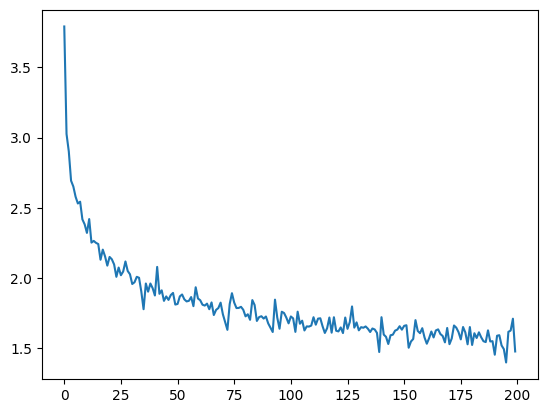

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

# Evaluating the results

In [34]:
print(evaluate('Th', 200, temperature=0.8))

The sild.  It to minisher you've not I ton, and size was and any minut as yeent herself would she was the dish antice as rather armsancer, said the King to Alice the hast
off the Queep, and the firsting


In [35]:
print(evaluate('Th', 200, temperature=1.4))

ThE-in-My'll "WYM itly.

  Fourratuen'guldrynhy;
omsiniight MIM HD ass.'

  `"We wour,
of "Tul, it:  `Thaps:
        Alifure begor lesper, your fold
bery
f, I
helt I'--inver shountullarmier: in theantry


In [37]:
print(evaluate('Th', 200, temperature=0.5))

There of the time as a first had to she sort of herself she triester the rather a very all the Queen to grash the door to she came was as a could of crow the March Freat was at the had to her a contied,
